## Human Activity Recognition (HAR) - Pre Processsed Sensor Signals

### Objectif

Construire un réseau de neurones capable d'identifier l'activité réalisée par une personne à partir de mesures issues des capteurs d'un smartphone (accéléromètre et gyroscope).

### Dataset

Le dataset UCI HAR contient des signaux prétraités décrivant les mouvements de plusieurs individus.

- **561 features** en entrée
- **6 classes** :
  - Walking
  - Walking Upstairs
  - Walking Downstairs
  - Sitting
  - Standing
  - Laying

### Approche

1. Chargement et préparation des données
2. Construction d'un MLP avec PyTorch
3. Entraînement du modèle
4. Évaluation sur le jeu de test
5. Analyse des métriques (Accuracy et Cross-Entropy Loss)

In [1]:
import os
import requests
import zipfile
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# 1. Téléchargement et extraction (automatique)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI HAR Dataset.zip"
zip_path = "UCI_HAR_Dataset.zip"
extract_folder = "UCI HAR Dataset"

if not os.path.exists(extract_folder):
    print("Téléchargement du dataset en cours (environ 60 Mo)...")
    response = requests.get(url)
    with open(zip_path, 'wb') as f:
        f.write(response.content)
    
    print("Extraction...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("Terminé !")
else:
    print("Le dataset est déjà présent sur ton PC.")

# 2. Chargement des données avec Pandas 

print("Chargement des fichiers txt en mémoire...")
X_train_df = pd.read_csv(f'{extract_folder}/train/X_train.txt', sep=r'\s+', header=None)
y_train_df = pd.read_csv(f'{extract_folder}/train/y_train.txt', sep=r'\s+', header=None)

X_test_df = pd.read_csv(f'{extract_folder}/test/X_test.txt', sep=r'\s+', header=None)
y_test_df = pd.read_csv(f'{extract_folder}/test/y_test.txt', sep=r'\s+', header=None)

# 3. Conversion en Tensors PyTorch
X_train = torch.tensor(X_train_df.values, dtype=torch.float32)
X_test = torch.tensor(X_test_df.values, dtype=torch.float32)

# ATTENTION : Dans le dataset, les labels vont de 1 à 6. 
# Classification multi-classes PyTorch : indexation des classes débutent par 0 / entiers requis -> dtype=torch.long
y_train = torch.tensor(y_train_df.values - 1, dtype=torch.long).squeeze()
y_test = torch.tensor(y_test_df.values - 1, dtype=torch.long).squeeze()

print(f"\nForme de X_train : {X_train.shape} -> (Il y a 7352 exemples, chacun ayant 561 features)")
print(f"Forme de y_train : {y_train.shape} -> (7352 étiquettes de 0 à 5)")

Le dataset est déjà présent sur ton PC.
Chargement des fichiers txt en mémoire...

Forme de X_train : torch.Size([7352, 561]) -> (Il y a 7352 exemples, chacun ayant 561 features)
Forme de y_train : torch.Size([7352]) -> (7352 étiquettes de 0 à 5)


In [3]:
# CREATION DATAS BATCHS

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=100, shuffle=True)      # Contient un X_batch et y_batch

In [4]:
# STRUCTURE DU RESEAU DE NEURONES

class Model(nn.Module):     # Model => héritage de la classe Module 

    def __init__(self, n_layers, n_neurons):
        super().__init__()      # Appel le constructeur de Module : donne accès aux méthodes (.parameters() / .train() / .eval() / ...)
        
        # Couche d'entrée :
        self.lin1 = nn.Linear(561, n_neurons, bias=False)
        self.batchN1 = nn.BatchNorm1d(n_neurons)

        # Couches cachées :
        self.hidden_layers = nn.ModuleList()
        
        for i in range(n_layers - 2):
            block = nn.Sequential(
                nn.Linear(n_neurons, n_neurons, bias=False),
                nn.BatchNorm1d(n_neurons),
                nn.ReLU(),
                nn.Dropout(p=0.5)       # Éteint 50% des neurones de ce bloc au hasard 
            )
            self.hidden_layers.append(block)

        self.lin_out = nn.Linear(n_neurons, 6)

    def forward(self, x):
        x = self.lin1(x)
        x = self.batchN1(x)
        x = F.relu(x)

        for layer_block in self.hidden_layers:
            x = layer_block(x)

        x = self.lin_out(x)

        return x 


In [5]:
# CREATION DU RESEAU DE NEURONES
#  
mlp = Model(n_layers=5, n_neurons=100)

In [6]:
# FONCTION ACCURACY TRAINING

def accuracy(Model):

    Model.eval()      

    correct = 0
    total = 0

    with torch.no_grad():
            
        y_predt = Model(X_test)

        res_pred = y_predt.max(1).indices
        correct += (res_pred == y_test).float().sum()
        total += y_test.size(0)
        
        accuracy = (correct / total)*100
        
        return accuracy

In [ ]:
# Training

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.01)

epochs = 100
best_acc = 0

update_ratios = []
steps = []
global_step = 0

for epoch in range(epochs):

    mlp.train()
    
    for X_batch, y_batch in loader:

        # Foward pass : 
        y_pred = mlp(X_batch)

        # Loss :
        loss = criterion(y_pred, y_batch)
        if global_step == 0:
            print(f"Premier loss = {loss.item():.4f}")

        # Reset Grad :
        optimizer.zero_grad()

        # Back pass :
        loss.backward()

        #Calcul des weights avant update
        with torch.no_grad():
            weights_before = mlp.lin_out.weight.clone()

        # Update Weights :
        optimizer.step()
    
        # Diagnostique :
        with torch.no_grad():
            global_step +=1
            steps.append(global_step) 

            weights_after = mlp.lin_out.weight
            taille_pas = (weights_after - weights_before).abs().mean()
            update_ratio = torch.log10(taille_pas / weights_after.abs().mean() + 1e-8)
            update_ratios.append(update_ratio)

    # Test après chaque epoch => éviter l'overtraining
    current_acc = accuracy(mlp)
    print(f"Epoch {epoch:02d} | Loss Train: {loss.item():.4f} | Acc Test: {current_acc:.2f}%")
        
    if best_acc <= current_acc :
        best_acc = current_acc
        torch.save(mlp.state_dict(), 'best_model_HAR1.pth')
          
print(f"Meilleur précision : {best_acc:.2f}")
        

Premier loss = 0.3203
Epoch 00 | Loss Train: 0.3308 | Acc Test: 87.78%
Epoch 01 | Loss Train: 0.2672 | Acc Test: 83.14%
Epoch 02 | Loss Train: 0.2234 | Acc Test: 93.21%
Epoch 03 | Loss Train: 0.0929 | Acc Test: 92.16%
Epoch 04 | Loss Train: 0.0516 | Acc Test: 92.06%
Epoch 05 | Loss Train: 0.2246 | Acc Test: 94.40%
Epoch 06 | Loss Train: 0.0840 | Acc Test: 92.47%
Epoch 07 | Loss Train: 0.0476 | Acc Test: 92.70%
Epoch 08 | Loss Train: 0.0101 | Acc Test: 95.25%
Epoch 09 | Loss Train: 0.0304 | Acc Test: 94.20%
Epoch 10 | Loss Train: 0.0172 | Acc Test: 87.82%
Epoch 11 | Loss Train: 0.0059 | Acc Test: 93.76%
Epoch 12 | Loss Train: 0.1252 | Acc Test: 90.30%
Epoch 13 | Loss Train: 0.0918 | Acc Test: 95.32%
Epoch 14 | Loss Train: 0.0159 | Acc Test: 94.27%
Epoch 15 | Loss Train: 0.1544 | Acc Test: 86.02%
Epoch 16 | Loss Train: 0.3091 | Acc Test: 94.88%
Epoch 17 | Loss Train: 0.0560 | Acc Test: 93.25%
Epoch 18 | Loss Train: 0.1142 | Acc Test: 94.30%
Epoch 19 | Loss Train: 0.0182 | Acc Test: 93.11

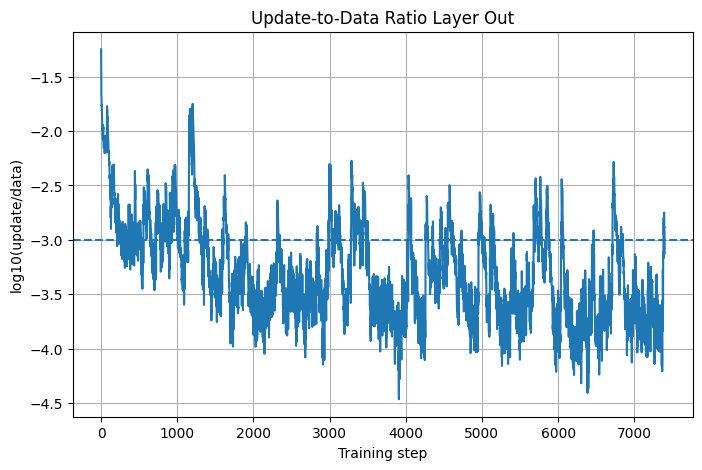

In [10]:
# AFFICHAGE DE L'UPDATE RATIO

plt.figure(figsize=(8,5))
plt.plot(steps, update_ratios)
plt.axhline(-3, linestyle='--')
plt.xlabel("Training step")
plt.ylabel("log10(update/data)")
plt.title("Update-to-Data Ratio Layer Out")
plt.grid(True)
plt.show()

In [11]:
# RECUPERATION DU BEST MODEL

# Étape 1 : Réinstancier l'architecture
best_mlp = Model(n_layers=5, n_neurons=100)

# Étape 2 : Chargement du dictionnaire de paramètres (disque dur -> VRAM)
paramètres = torch.load('best_model_HAR1.pth')

# Étape 3 : Injectes des paramètres dans l'architecture 
best_mlp.load_state_dict(paramètres)

<All keys matched successfully>

In [12]:
# Phase de test

best_mlp.eval()      # BatchNorm1d : running_mean & running_std / Stop Dropout

with torch.no_grad():
    
    y_predt = best_mlp(X_test)
    loss_test = criterion(y_predt, y_test)
    print(f"Test Loss : {loss_test.item():.6f}")

    res_pred = y_predt.max(1).indices
    accuracy = (res_pred == y_test).float().mean()
    print(f"Précision sur le Test : {accuracy.item() * 100:.2f} %")

    

Test Loss : 0.162171
Précision sur le Test : 96.40 %


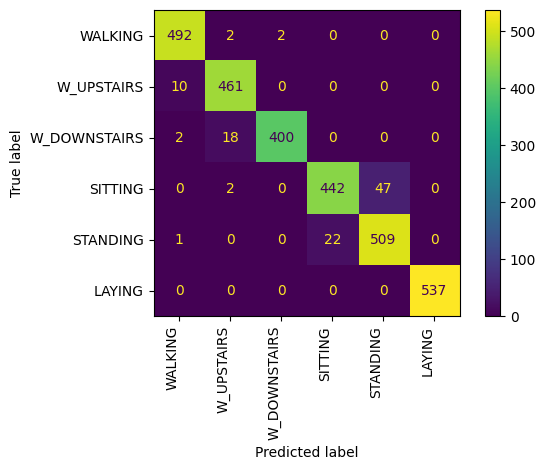

In [18]:
# MATRICE DE CONFUSION

best_mlp.eval()      

all_pred = []
all_true = []

with torch.no_grad():
      
    y_predt = best_mlp(X_test)
    pred = y_predt.argmax(dim=1)

    all_pred.extend(pred.numpy())
    all_true.extend(y_test.numpy())

    cm = confusion_matrix(all_true, all_pred, normalize=None)

activity_names = ['WALKING', 'W_UPSTAIRS', 'W_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_names)
disp.plot()

plt.xticks(rotation=90, ha='right')
plt.tight_layout()

plt.show()